Removing zero-variance columns from X_full_model: ['Moving Forward']


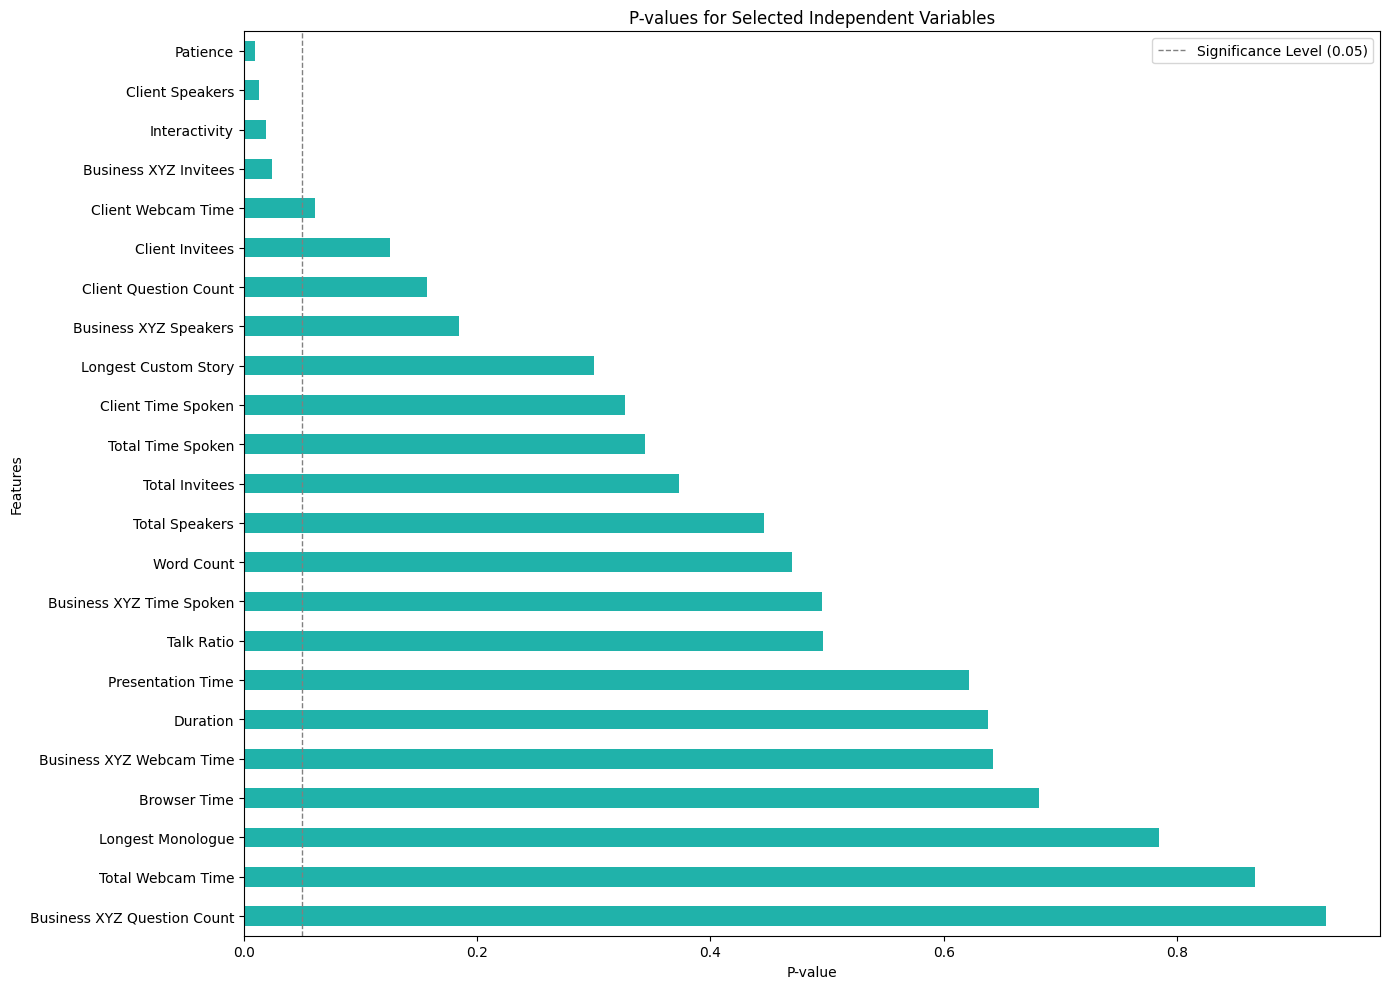

P-values for Selected Independent Variables:
Business XYZ Question Count    0.927538
Total Webcam Time              0.866796
Longest Monologue              0.784834
Browser Time                   0.681972
Business XYZ Webcam Time       0.642566
Duration                       0.637518
Presentation Time              0.621432
Talk Ratio                     0.496738
Business XYZ Time Spoken       0.496024
Word Count                     0.470271
Total Speakers                 0.445684
Total Invitees                 0.372901
Total Time Spoken              0.343580
Client Time Spoken             0.326934
Longest Custom Story           0.300031
Business XYZ Speakers          0.184639
Client Question Count          0.157454
Client Invitees                0.125564
Client Webcam Time             0.060959
Business XYZ Invitees          0.024398
Interactivity                  0.018806
Client Speakers                0.013320
Patience                       0.010021
dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.api as sm
import numpy as np
from sklearn.preprocessing import StandardScaler
from google.colab import files
import os

# --- Start of Data Loading and Preprocessing for X and y (copied from earlier steps) ---

# Check if the file exists, if not, prompt for upload
file_path = '/content/CallData.csv'
if not os.path.exists(file_path):
    print("CallData.csv not found. Please upload the file.")
    uploaded = files.upload()
    for fn in uploaded.keys():
        print('User uploaded file "{name}" with length {length} bytes'.format(
            name=fn, length=len(uploaded[fn])))
    if 'CallData.csv' not in uploaded:
        print("Error: CallData.csv was not uploaded. Please upload the correct file.")
        # You might want to exit or raise an error here if the file is critical
        raise FileNotFoundError("CallData.csv not uploaded.")

# Load the CallData.csv file into a Pandas DataFrame
df = pd.read_csv(file_path)

# Identify column indices for selection
columns = df.columns.tolist()
d_col_index = columns.index('Duration (Sec.)')
ae_col_index = columns.index('Deal Stage (After)')
aj_col_index = columns.index('Binary Success')
ak_col_index = columns.index('Verbal AS-IS (generic phrases) - # Occurrences')
bd_col_index = columns.index('Wrap-Up')

# Select the dependent variable (AJ)
y = df.iloc[:, aj_col_index]

# Select independent variables (D to AE and AK to BD)
X_part1 = df.iloc[:, d_col_index : ae_col_index + 1]
X_part2 = df.iloc[:, ak_col_index : bd_col_index + 1]
X = pd.concat([X_part1, X_part2], axis=1)

# Remove rows from both X and y where the dependent variable y ('Binary Success') has missing values.
non_null_indices = y.dropna().index
X = X.loc[non_null_indices]
y = y.loc[non_null_indices]

# Drop the original categorical columns 'Deal Stage (After)' and 'Deal Stage (Before)' from X.
columns_to_drop = ['Deal Stage (After)', 'Deal Stage (Before)']
X = X.drop(columns=columns_to_drop, errors='ignore')

# Identify numerical columns in X that still contain missing values and impute them with the mean.
missing_values_count = X.isnull().sum()
missing_numerical_cols = missing_values_count[missing_values_count > 0].index.tolist()
for col in missing_numerical_cols:
    if X[col].dtype in ['int64', 'float64']:
        X[col] = X[col].fillna(X[col].mean())

# Confirm that all remaining columns in X are numerical.
non_numerical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
if non_numerical_cols:
    X = pd.get_dummies(X, columns=non_numerical_cols, drop_first=True)

# Ensure y is binary (0 or 1)
if not y.isin([0, 1]).all():
    y = (y > 0).astype(int)

# Apply StandardScaler to all columns in X to scale the numerical features.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

# Add a constant (intercept) term to the independent variables DataFrame X
X = sm.add_constant(X)

# --- End of Data Loading and Preprocessing for X and y ---

# If 'const' is already in X, dropping it and re-adding ensures it's at the beginning and handled correctly.
if 'const' in X.columns:
    X_full_model = X.drop(columns=['const'])
else:
    X_full_model = X.copy() # Use the already prepared X
X_full_model = sm.add_constant(X_full_model)

# Identify and remove columns with zero variance (which are constant and cause multicollinearity after scaling)
# Exclude the 'const' column from this check as it is intentionally constant.
zero_variance_cols = [col for col in X_full_model.columns if col != 'const' and X_full_model[col].std() == 0]

if zero_variance_cols:
    print(f"Removing zero-variance columns from X_full_model: {zero_variance_cols}")
    X_full_model = X_full_model.drop(columns=zero_variance_cols)

# Fit the logistic regression model with all remaining features
# Use 'bfgs' method and increase maxiter for better convergence, similar to the backward elimination loop
full_model = sm.Logit(y, X_full_model).fit(disp=0, method='bfgs', maxiter=1000)

# Get p-values for all features including the constant
all_p_values = full_model.pvalues

# Sort p-values for better visualization
all_p_values_sorted = all_p_values.sort_values(ascending=False)


# Define the mapping from original column names to user-friendly names
variable_mapping = {
    'Duration (Sec.)': 'Duration',
    'Word Count': 'Word Count',
    'Total Invitees Count': 'Total Invitees',
    'HighRadius Invitee Count': 'Business XYZ Invitees',
    'Non-HighRadius Invitee Count': 'Client Invitees',
    'Total Speakers Count': 'Total Speakers',
    'HighRadius Speaker Count': 'Business XYZ Speakers',
    'Non-HighRadius Speaker Count': 'Client Speakers',
    'Total Time Spoken': 'Total Time Spoken',
    'HighRadius Time Spoken': 'Business XYZ Time Spoken',
    'Non-HighRadius Time Spoken': 'Client Time Spoken',
    'HighRadius Question Count': 'Business XYZ Question Count',
    'Non-HighRadius Question Count': 'Client Question Count',
    'Browser (Sec.)': 'Browser Time',
    'Presentation (Sec.)': 'Presentation Time',
    'Webcam (Sec.)': 'Total Webcam Time',
    'Webcam Primary User (Sec.)': 'Business XYZ Webcam Time',
    'Webcam Non-Company (Sec.)': 'Client Webcam Time',
    'Talk Ratio (%)': 'Talk Ratio',
    'Longest Monologue (Sec.)': 'Longest Monologue',
    'Longest Customer Story (Sec.)': 'Longest Custom Story',
    'Patience': 'Patience',
    'Interactivity (0-10 Scale)': 'Interactivity'
}

# Filter the p-values for the specified variables
filtered_p_values = all_p_values_sorted[all_p_values_sorted.index.isin(variable_mapping.keys())]

# Rename the index (features) using the mapping
renamed_p_values = filtered_p_values.rename(index=variable_mapping)

# Sort the renamed p-values for plotting
renamed_p_values_sorted = renamed_p_values.sort_values(ascending=False)

# Plotting the filtered and renamed p-values
plt.figure(figsize=(14, 10))
renamed_p_values_sorted.plot(kind='barh', color='lightseagreen')
plt.xlabel('P-value')
plt.ylabel('Features')
plt.title('P-values for Selected Independent Variables')
plt.axvline(x=0.05, color='grey', linestyle='--', linewidth=1, label='Significance Level (0.05)')
plt.legend()
plt.grid(axis='x', linestyle='--', alpha=0)
plt.tight_layout()
plt.show()

print("P-values for Selected Independent Variables:")
print(renamed_p_values_sorted)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import pandas as pd

df = pd.read_csv('/content/CallData.csv')

print("First 5 rows of the DataFrame:")
print(df.head())

print("\nDataFrame Info:")
df.info()

First 5 rows of the DataFrame:
  Gong Internal Call ID        Recorded Date Language  Duration (Sec.)  \
0  _7545492036678756386  06-30-2025 23:30:46      eng             1796   
1  _4280164938572647668  06-30-2025 18:29:47      eng             1933   
2  _1189015539144961677  06-27-2025 23:09:28      eng             1723   
3  _6279956696687584732  06-27-2025 14:35:07      fre             1501   
4  _2512901326253550071  06-26-2025 21:31:31      eng             1891   

   Word Count  HighRadius Invitee Count  Non-HighRadius Invitee Count  \
0        4346                         1                             3   
1        4754                         5                             1   
2        4984                         1                             1   
3        4129                         3                             1   
4        5003                         0                             1   

   Total Invitees Count  HighRadius Attendee Count  \
0                   4.0        

In [ ]:
columns = df.columns.tolist()

# Identify column indices for selection
d_col_index = columns.index('Duration (Sec.)')
ae_col_index = columns.index('Deal Stage (After)')
aj_col_index = columns.index('Binary Success')
ak_col_index = columns.index('Verbal AS-IS (generic phrases) - # Occurrences')
bd_col_index = columns.index('Wrap-Up')

# Select the dependent variable (AJ)
y = df.iloc[:, aj_col_index]

# Select independent variables (D to AE and AK to BD)
X_part1 = df.iloc[:, d_col_index : ae_col_index + 1]
X_part2 = df.iloc[:, ak_col_index : bd_col_index + 1]
X = pd.concat([X_part1, X_part2], axis=1)

print("Shape of dependent variable (y):")
print(y.shape)
print("\nFirst 5 values of dependent variable (y):")
print(y.head())

print("\nShape of independent variables (X):")
print(X.shape)
print("\nFirst 5 rows of independent variables (X):")
print(X.head())

Shape of dependent variable (y):
(8190,)

First 5 values of dependent variable (y):
0    0.0
1    0.0
2    1.0
3    0.0
4    0.0
Name: Binary Success, dtype: float64

Shape of independent variables (X):
(8190, 49)

First 5 rows of independent variables (X):
   Duration (Sec.)  Word Count  HighRadius Invitee Count  \
0             1796        4346                         1   
1             1933        4754                         5   
2             1723        4984                         1   
3             1501        4129                         3   
4             1891        5003                         0   

   Non-HighRadius Invitee Count  Total Invitees Count  \
0                             3                   4.0   
1                             1                   6.0   
2                             1                   2.0   
3                             1                   4.0   
4                             1                   1.0   

   HighRadius Attendee Count  Non-High

In [ ]:
import numpy as np

# Step 1: Remove rows from both X and y where the dependent variable y ('Binary Success') has missing values.
# Identify non-null indices in y
non_null_indices = y.dropna().index

# Filter X and y using these indices
X = X.loc[non_null_indices]
y = y.loc[non_null_indices]

print(f"Shape of X after removing NaNs in y: {X.shape}")
print(f"Shape of y after removing NaNs in y: {y.shape}")

# Step 2: Drop the original categorical columns 'Deal Stage (After)' and 'Deal Stage (Before)' from X.
columns_to_drop = ['Deal Stage (After)', 'Deal Stage (Before)']
X = X.drop(columns=columns_to_drop, errors='ignore')

print(f"Shape of X after dropping categorical columns: {X.shape}")
print("Columns in X after dropping:")
print(X.columns.tolist())

Shape of X after removing NaNs in y: (5104, 49)
Shape of y after removing NaNs in y: (5104,)
Shape of X after dropping categorical columns: (5104, 48)
Columns in X after dropping:
['Duration (Sec.)', 'Word Count', 'HighRadius Invitee Count', 'Non-HighRadius Invitee Count', 'Total Invitees Count', 'HighRadius Attendee Count', 'Non-HighRadius Attendee Count', 'Total Attendees Count', 'HighRadius Speaker Count', 'Non-HighRadius Speaker Count', 'Total Speakers Count', 'Total Time Spoken', 'Host Time Spoken', 'HighRadius Time Spoken', 'Non-HighRadius Time Spoken', 'Host Question Count', 'HighRadius Question Count', 'Non-HighRadius Question Count', 'Browser (Sec.)', 'Presentation (Sec.)', 'Webcam Primary User (Sec.)', 'Webcam Non-Company (Sec.)', 'Webcam (Sec.)', 'Talk Ratio (%)', 'Longest Monologue (Sec.)', 'Longest Customer Story (Sec.)', 'Patience', 'Interactivity (0-10 Scale)', 'Verbal AS-IS (generic phrases) - # Occurrences', 'Cash Flow Management - # Occurrences', 'Collections App - # 

In [ ]:
from sklearn.preprocessing import StandardScaler

# Step 3: Identify numerical columns in X that still contain missing values and impute them with the mean.
# Check for missing values in X
missing_values_count = X.isnull().sum()
missing_numerical_cols = missing_values_count[missing_values_count > 0].index.tolist()

print("Columns with missing values before imputation:", missing_numerical_cols)

for col in missing_numerical_cols:
    if X[col].dtype in ['int64', 'float64']:
        X[col] = X[col].fillna(X[col].mean())

print("Missing values after imputation:")
print(X.isnull().sum().sum()) # Should be 0

# Step 4: Confirm that all remaining columns in X are numerical.
# Identify non-numerical columns
non_numerical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

if non_numerical_cols:
    print(f"Found non-numerical columns: {non_numerical_cols}. Applying one-hot encoding.")
    X = pd.get_dummies(X, columns=non_numerical_cols, drop_first=True) # drop_first to avoid multicollinearity
else:
    print("All columns in X are numerical.")

# Ensure y is binary (0 or 1)
if not y.isin([0, 1]).all():
    print("Warning: Dependent variable y is not strictly binary (0 or 1). Converting to 0/1.")
    # Assuming the intent is to convert to binary if not already, e.g., if it contains other values.
    # For this specific dataset, we expect it to be 0 or 1 already, but good to check.
    y = (y > 0).astype(int)

print(f"Unique values in y after check: {y.unique()}")

# Step 5: Import StandardScaler and apply it to all columns in X to scale the numerical features.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

print("\nShape of independent variables (X) after scaling:")
print(X.shape)
print("\nFirst 5 rows of independent variables (X) after scaling:")
print(X.head())

Columns with missing values before imputation: ['Total Invitees Count', 'Total Speakers Count']
Missing values after imputation:
0
All columns in X are numerical.
Unique values in y after check: [0. 1.]

Shape of independent variables (X) after scaling:
(5104, 48)

First 5 rows of independent variables (X) after scaling:
   Duration (Sec.)  Word Count  HighRadius Invitee Count  \
0        -0.118280    0.012917                 -0.751844   
1         0.243452    0.375240                  1.373852   
2        -0.311028    0.579490                 -0.751844   
3        -0.897192   -0.179789                  0.311004   
4         0.132556    0.596363                 -1.283268   

   Non-HighRadius Invitee Count  Total Invitees Count  \
0                      0.053782             -0.358245   
1                     -0.703462              0.184271   
2                     -0.703462             -0.900761   
3                     -0.703462             -0.358245   
4                     -0.703462

In [ ]:
import statsmodels.api as sm

# Add a constant (intercept) term to the independent variables DataFrame X
X = sm.add_constant(X)

print("Shape of X after adding constant:")
print(X.shape)
print("Columns in X after adding constant:")
print(X.columns.tolist()[:5], "...", X.columns.tolist()[-5:])

Shape of X after adding constant:
(5104, 49)
Columns in X after adding constant:
['const', 'Duration (Sec.)', 'Word Count', 'HighRadius Invitee Count', 'Non-HighRadius Invitee Count'] ... ['Small Talk', 'Moving Forward', 'Pricing', 'Next Steps', 'Wrap-Up']


In [ ]:
selected_features = X.columns.tolist()

# Implement backward elimination loop
while True:
    # Fit the logistic regression model
    model = sm.Logit(y, X[selected_features]).fit(disp=0) # disp=0 suppresses convergence messages

    # Get p-values
    p_values = model.pvalues

    # Identify the feature with the highest p-value, excluding the constant
    # Filter out 'const' from p_values for elimination consideration
    p_values_to_consider = p_values.drop('const', errors='ignore')

    if p_values_to_consider.empty:
        break # No more features to consider for elimination

    max_p_value = p_values_to_consider.max()
    feature_to_remove = p_values_to_consider.idxmax()

    # Check if the highest p-value is greater than 0.05
    if max_p_value > 0.05:
        selected_features.remove(feature_to_remove)
        print(f"Removing '{feature_to_remove}' with p-value: {max_p_value:.4f}")
    else:
        break # All remaining features are significant

print("\n--- Final Model Summary ---")
final_model = sm.Logit(y, X[selected_features]).fit(disp=0)
print(final_model.summary())

LinAlgError: Singular matrix

In [ ]:
selected_features = X.columns.tolist()

# Implement backward elimination loop
while True:
    try:
        # Fit the logistic regression model using 'bfgs' method for better robustness against singular matrix errors
        model = sm.Logit(y, X[selected_features]).fit(disp=0, method='bfgs')

        # Get p-values
        p_values = model.pvalues

        # Identify the feature with the highest p-value, excluding the constant
        # Filter out 'const' from p_values for elimination consideration
        p_values_to_consider = p_values.drop('const', errors='ignore')

        if p_values_to_consider.empty:
            break # No more features to consider for elimination

        max_p_value = p_values_to_consider.max()
        feature_to_remove = p_values_to_consider.idxmax()

        # Check if the highest p-value is greater than 0.05
        if max_p_value > 0.05:
            selected_features.remove(feature_to_remove)
            print(f"Removing '{feature_to_remove}' with p-value: {max_p_value:.4f}")
        else:
            break # All remaining features are significant

    except np.linalg.LinAlgError as e:
        # If a singular matrix error occurs, print a message and break or try to remove a feature if possible
        print(f"LinAlgError encountered: {e}. Attempting to remove a feature to resolve.")
        # This part might need more sophisticated handling, but for now, let's remove the feature with highest p-value before the error if available
        # Or, we could try to remove the last feature added if this is an issue during the first iteration
        if not p_values_to_consider.empty:
            feature_to_remove_on_error = p_values_to_consider.idxmax()
            if feature_to_remove_on_error in selected_features:
                selected_features.remove(feature_to_remove_on_error)
                print(f"Forcing removal of '{feature_to_remove_on_error}' due to LinAlgError.")
            else:
                print("No obvious feature to remove from current selected_features to resolve LinAlgError.")
                break
        else:
            print("Cannot proceed with backward elimination; no features to remove to resolve LinAlgError.")
            break
    except Exception as e:
        print(f"An unexpected error occurred: {e}")
        break

print("\n--- Final Model Summary ---")
final_model = sm.Logit(y, X[selected_features]).fit(disp=0, method='bfgs') # Refit final model with bfgs
print(final_model.summary())


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/tmp/ipython-input-3755999600.py:20: FutureWarning: The behavior of Series.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  feature_to_remove = p_values_to_consider.idxmax()
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maxim


--- Final Model Summary ---
                           Logit Regression Results                           
Dep. Variable:         Binary Success   No. Observations:                 5104
Model:                          Logit   Df Residuals:                     5057
Method:                           MLE   Df Model:                           46
Date:                Tue, 24 Feb 2026   Pseudo R-squ.:                 0.02467
Time:                        02:13:41   Log-Likelihood:                -2874.9
converged:                      False   LL-Null:                       -2947.6
Covariance Type:            nonrobust   LLR p-value:                 2.980e-12
                                                     coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------
const                                             -1.0594        nan        nan        nan         nan       

In [ ]:
selected_features = X.columns.tolist()

# Implement backward elimination loop
while True:
    try:
        # Fit the logistic regression model using 'bfgs' method for better robustness
        # Increased maxiter for better convergence chance
        model = sm.Logit(y, X[selected_features]).fit(disp=0, method='bfgs', maxiter=1000)

        p_values = model.pvalues.drop('const', errors='ignore')

        # Check for features with NaN p-values (indicating severe multicollinearity or numerical issues)
        nan_p_values_features = p_values[p_values.isnull()].index.tolist()

        if nan_p_values_features:
            # If there are features with NaN p-values, remove one of them
            feature_to_remove_due_to_nan = nan_p_values_features[0]
            selected_features.remove(feature_to_remove_due_to_nan)
            print(f"Removing '{feature_to_remove_due_to_nan}' due to NaN p-value (likely multicollinearity). Remaining features: {len(selected_features) - 1}")
            continue # Continue to the next iteration to refit

        # If no NaN p-values, proceed with standard backward elimination
        if p_values.empty: # This means only 'const' is left, or no features to evaluate
            break

        max_p_value = p_values.max()
        feature_to_remove = p_values.idxmax() # This should now work as no NaNs are present

        # Check if the highest p-value is greater than 0.05
        if max_p_value > 0.05:
            selected_features.remove(feature_to_remove)
            print(f"Removing '{feature_to_remove}' with p-value: {max_p_value:.4f}. Remaining features: {len(selected_features) - 1}")
        else:
            break # All remaining features are significant

    except np.linalg.LinAlgError as e:
        print(f"LinAlgError encountered during model fit: {e}.")
        print("This typically indicates perfect multicollinearity. Attempting to remove a feature heuristically.")

        problem_found = False
        non_const_cols = [col for col in selected_features if col != 'const']

        # Check for constant columns within the current X[selected_features]
        for col in non_const_cols:
            if X[col].nunique() == 1: # If only one unique value (i.e., constant)
                selected_features.remove(col)
                print(f"Forcing removal of constant feature '{col}' due to LinAlgError. Remaining features: {len(selected_features) - 1}")
                problem_found = True
                break

        # If no constant column was found, or the error persists, try removing 'Moving Forward' if present
        if not problem_found and 'Moving Forward' in selected_features:
             selected_features.remove('Moving Forward')
             print("Forcing removal of 'Moving Forward' due to suspected multicollinearity/singularity.")
             problem_found = True

        if not problem_found: # If no specific problematic column identified heuristically
            if non_const_cols: # If there are still non-constant columns
                # As a last resort, remove the feature with the highest numerical index (last one in the list)
                feature_to_remove_on_error = non_const_cols[-1]
                selected_features.remove(feature_to_remove_on_error)
                print(f"Forcing removal of '{feature_to_remove_on_error}' due to LinAlgError (heuristic). Remaining features: {len(selected_features) - 1}")
            else:
                print("Cannot proceed with backward elimination; no non-constant features to remove to resolve LinAlgError.")
                break # No more features to remove
        continue # Continue to the next iteration to refit

    except Exception as e:
        print(f"An unexpected error occurred during model fit: {e}")
        break

print("\n--- Final Model Summary ---")
# Refit the final model outside the loop to get the summary for the final features
if selected_features and (len(selected_features) > 1 or (len(selected_features) == 1 and 'const' in selected_features)): # Ensure there are features to fit
    final_model = sm.Logit(y, X[selected_features]).fit(disp=0, method='bfgs', maxiter=1000)
    print(final_model.summary())
else:
    print("No significant features found after backward elimination (or only 'const' remains).")


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '


Removing 'Duration (Sec.)' due to NaN p-value (likely multicollinearity). Remaining features: 47


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '


Removing 'Word Count' due to NaN p-value (likely multicollinearity). Remaining features: 46
Removing 'Moving Forward' with p-value: 1.0000. Remaining features: 45
Removing 'Total Attendees Count' with p-value: 1.0000. Remaining features: 44
Removing 'Host Question Count' with p-value: 0.9997. Remaining features: 43
Removing 'HighRadius Question Count' with p-value: 0.9400. Remaining features: 42
Removing 'Wrap-Up' with p-value: 0.9342. Remaining features: 41
Removing 'Webcam (Sec.)' with p-value: 0.8897. Remaining features: 40
Removing 'Longest Monologue (Sec.)' with p-value: 0.8051. Remaining features: 39
Removing 'HighRadius Attendee Count' with p-value: 0.7364. Remaining features: 38
Removing 'Webcam Primary User (Sec.)' with p-value: 0.6503. Remaining features: 37
Removing 'Verbal AS-IS (generic phrases) - # Occurrences' with p-value: 0.6054. Remaining features: 36
Removing 'Browser (Sec.)' with p-value: 0.6049. Remaining features: 35
Removing 'Presentation (Sec.)' with p-value: 0.

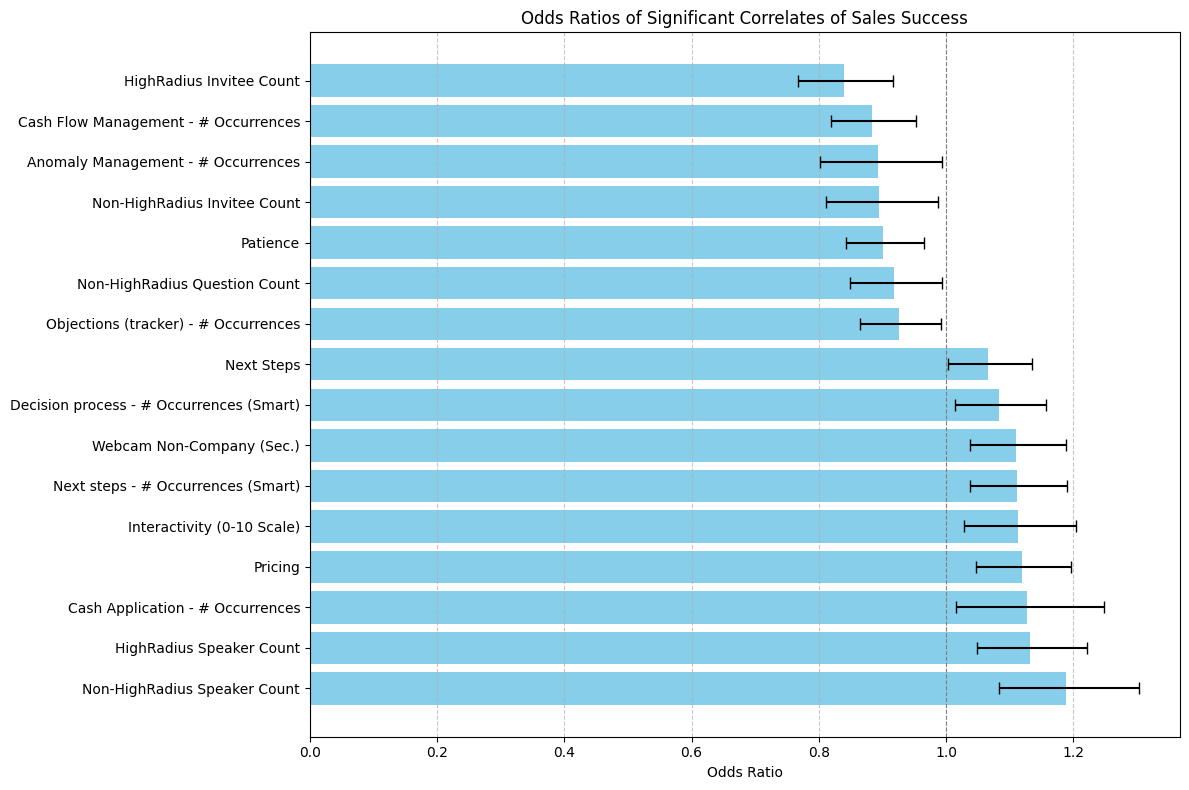

Odds Ratios for Significant Correlates:
                                     feature  odds_ratio  lower_ci  upper_ci
3               Non-HighRadius Speaker Count    1.187950  1.083478  1.302494
2                   HighRadius Speaker Count    1.131917  1.048731  1.221703
9           Cash Application - # Occurrences    1.126560  1.016262  1.248829
14                                   Pricing    1.119544  1.047343  1.196722
7                 Interactivity (0-10 Scale)    1.112491  1.028347  1.203519
13        Next steps - # Occurrences (Smart)    1.110910  1.037276  1.189770
5                  Webcam Non-Company (Sec.)    1.110620  1.037542  1.188846
12  Decision process - # Occurrences (Smart)    1.083131  1.013543  1.157497
15                                Next Steps    1.066576  1.002392  1.134869
10      Objections (tracker) - # Occurrences    0.926341  0.865273  0.991719
4              Non-HighRadius Question Count    0.918240  0.848267  0.993985
6                                   

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Extract coefficients and confidence intervals from the final model
params = final_model.params
conf = final_model.conf_int()

# Exclude the intercept ('const') for visualization of independent variables
params_no_const = params.drop('const', errors='ignore')
conf_no_const = conf.drop('const', errors='ignore')

# Calculate Odds Ratios
odds_ratios = np.exp(params_no_const)

# Calculate Odds Ratio Confidence Intervals
# Lower bound: exp(lower_conf_int)
# Upper bound: exp(upper_conf_int)
lower_ci = np.exp(conf_no_const[0])
upper_ci = np.exp(conf_no_const[1])

# Create a DataFrame for easier plotting
odds_df = pd.DataFrame({
    'feature': odds_ratios.index,
    'odds_ratio': odds_ratios.values,
    'lower_ci': lower_ci.values,
    'upper_ci': upper_ci.values
})

# Sort by odds ratio for better visualization
odds_df = odds_df.sort_values(by='odds_ratio', ascending=False)

# Plotting the Odds Ratios with Confidence Intervals
plt.figure(figsize=(12, 8))
plt.barh(odds_df['feature'], odds_df['odds_ratio'], xerr=[odds_df['odds_ratio'] - odds_df['lower_ci'], odds_df['upper_ci'] - odds_df['odds_ratio']], capsize=4, color='skyblue')
plt.xlabel('Odds Ratio')
plt.title('Odds Ratios of Significant Correlates of Sales Success')
plt.axvline(x=1, color='gray', linestyle='--', linewidth=0.8) # Reference line at Odds Ratio = 1
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Odds Ratios for Significant Correlates:")
print(odds_df)

Removing zero-variance columns from X_full_model: ['Moving Forward']


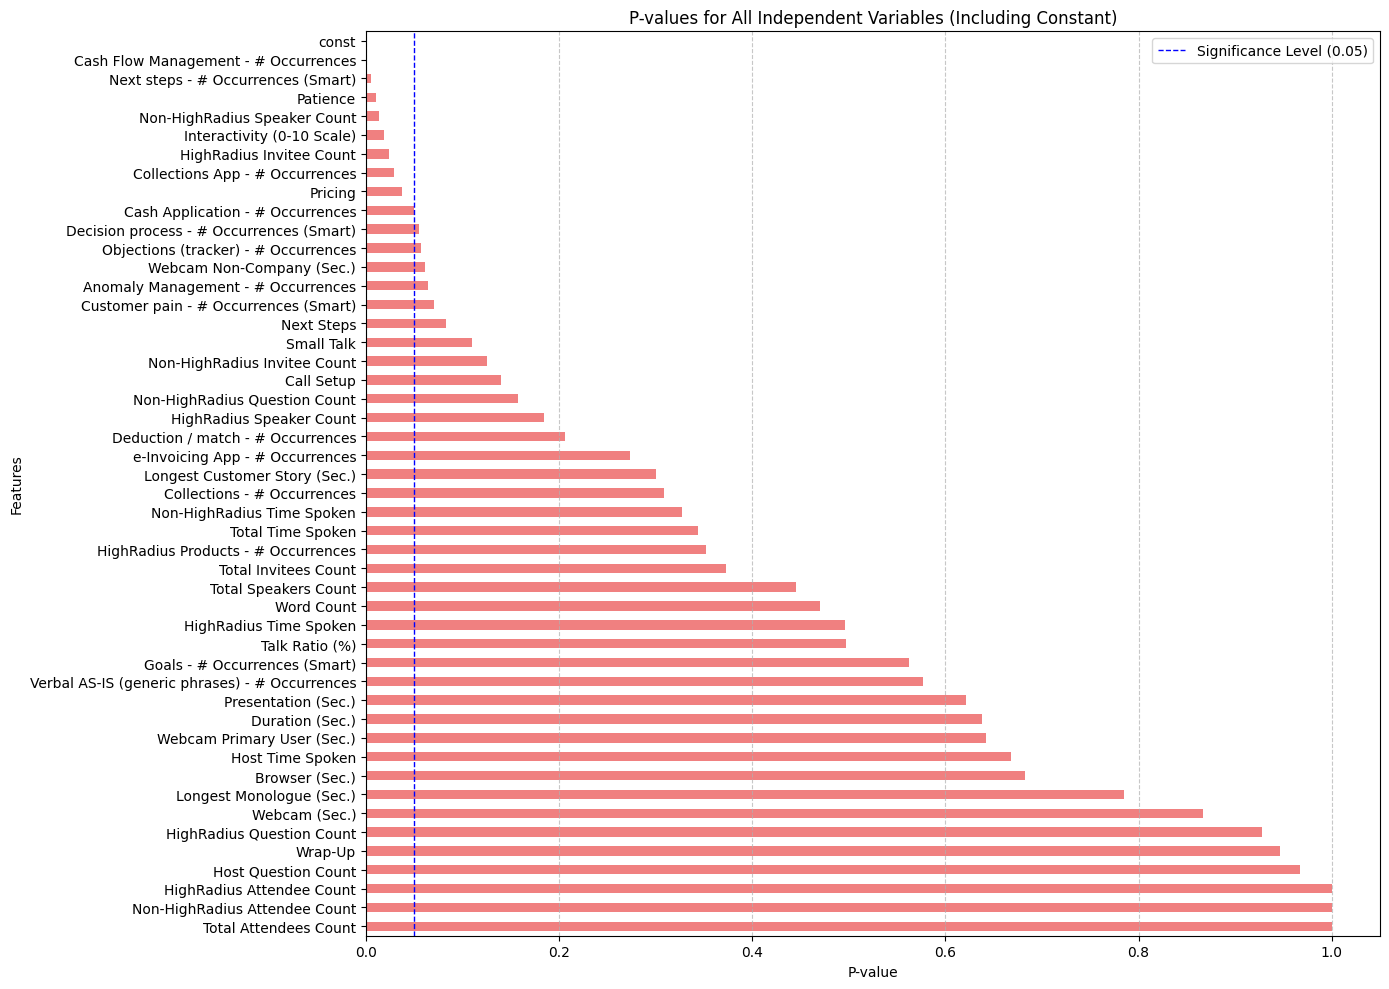

P-values for All Independent Variables:
Total Attendees Count                              1.000000e+00
Non-HighRadius Attendee Count                      1.000000e+00
HighRadius Attendee Count                          1.000000e+00
Host Question Count                                9.669228e-01
Wrap-Up                                            9.465419e-01
HighRadius Question Count                          9.275376e-01
Webcam (Sec.)                                      8.667961e-01
Longest Monologue (Sec.)                           7.848343e-01
Browser (Sec.)                                     6.819716e-01
Host Time Spoken                                   6.679783e-01
Webcam Primary User (Sec.)                         6.425662e-01
Duration (Sec.)                                    6.375185e-01
Presentation (Sec.)                                6.214321e-01
Verbal AS-IS (generic phrases) - # Occurrences     5.763519e-01
Goals - # Occurrences (Smart)                      5.622622e-01


In [ ]:
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Re-add the constant to the original X for the full model if it was removed in previous steps
# (Ensure X is the preprocessed and scaled version before adding constant if running independently)

# If 'const' is already in X, dropping it and re-adding ensures it's at the beginning and handled correctly.
if 'const' in X.columns:
    X_full_model = X.drop(columns=['const'])
else:
    X_full_model = X.copy() # Use the already prepared X
X_full_model = sm.add_constant(X_full_model)

# Identify and remove columns with zero variance (which are constant and cause multicollinearity after scaling)
# Exclude the 'const' column from this check as it is intentionally constant.
zero_variance_cols = [col for col in X_full_model.columns if col != 'const' and X_full_model[col].std() == 0]

if zero_variance_cols:
    print(f"Removing zero-variance columns from X_full_model: {zero_variance_cols}")
    X_full_model = X_full_model.drop(columns=zero_variance_cols)

# Fit the logistic regression model with all remaining features
# Use 'bfgs' method and increase maxiter for better convergence, similar to the backward elimination loop
full_model = sm.Logit(y, X_full_model).fit(disp=0, method='bfgs', maxiter=1000)

# Get p-values for all features including the constant
all_p_values = full_model.pvalues

# Sort p-values for better visualization
all_p_values_sorted = all_p_values.sort_values(ascending=False)

# Plotting the p-values
plt.figure(figsize=(14, 10))
all_p_values_sorted.plot(kind='barh', color='lightcoral')
plt.xlabel('P-value')
plt.ylabel('Features')
plt.title('P-values for All Independent Variables (Including Constant)')
plt.axvline(x=0.05, color='blue', linestyle='--', linewidth=1, label='Significance Level (0.05)')
plt.legend()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("P-values for All Independent Variables:")
print(all_p_values_sorted)

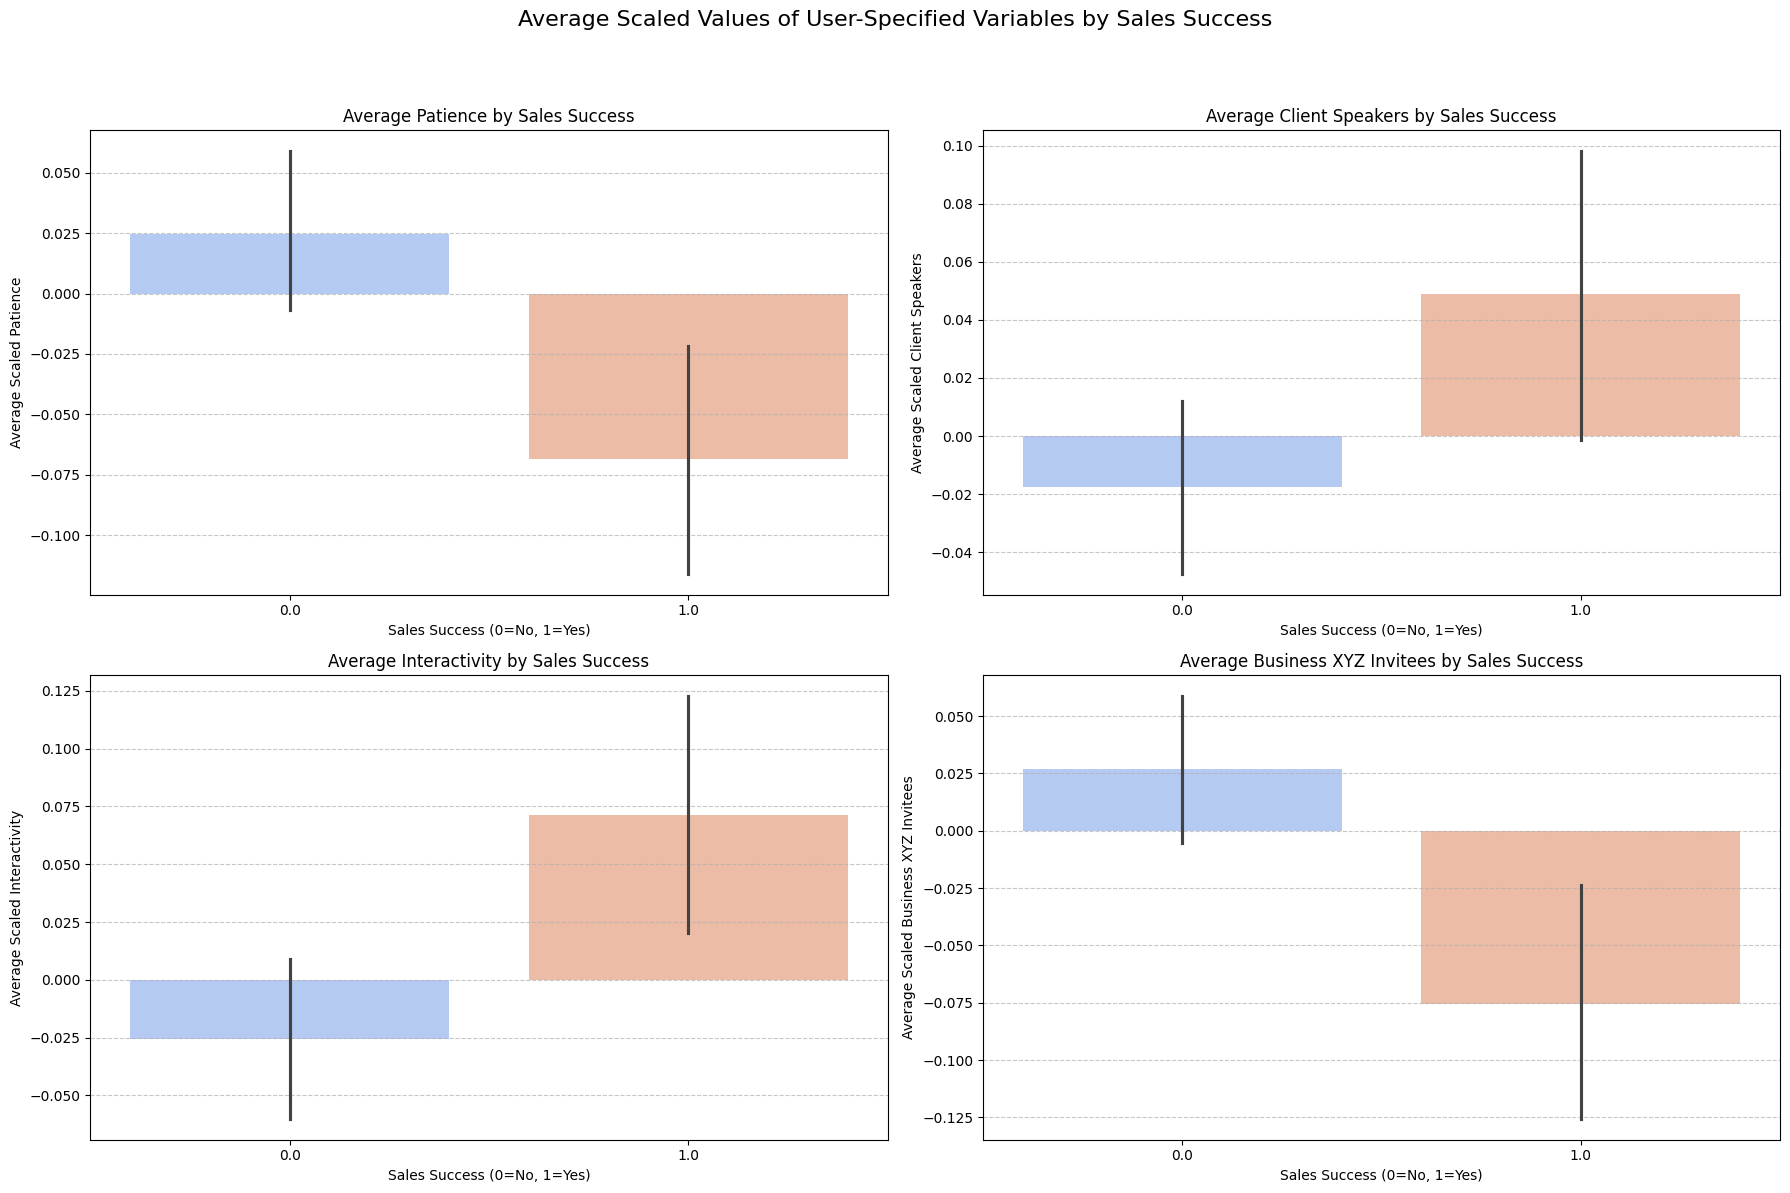

P-values for user-specified variables (from the final model):
Patience: 0.003541
Non-HighRadius Speaker Count: 0.001749
Interactivity (0-10 Scale): 0.047566
HighRadius Invitee Count: 0.000102


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import statsmodels.api as sm
import numpy as np
from sklearn.preprocessing import StandardScaler
from google.colab import files
import os

# --- Start of Data Loading and Preprocessing for X and y (copied from earlier steps) ---

# Check if the file exists, if not, prompt for upload
# Update file_path to the correct uploaded file name
file_path = '/content/AP Research Call Data - Call Data.csv'
if not os.path.exists(file_path):
    print("AP Research Call Data - Call Data.csv not found. Please upload the file.")
    uploaded = files.upload()
    for fn in uploaded.keys():
        print('User uploaded file "{name}" with length {length} bytes'.format(
            name=fn, length=len(uploaded[fn])))
    if 'AP Research Call Data - Call Data.csv' not in uploaded:
        print("Error: AP Research Call Data - Call Data.csv was not uploaded. Please upload the correct file.")
        raise FileNotFoundError("AP Research Call Data - Call Data.csv not uploaded.")

# Load the CallData.csv file into a Pandas DataFrame
df = pd.read_csv(file_path)

# Identify column indices for selection
columns = df.columns.tolist()
d_col_index = columns.index('Duration (Sec.)')
ae_col_index = columns.index('Deal Stage (After)')
aj_col_index = columns.index('Binary Success')
ak_col_index = columns.index('Verbal AS-IS (generic phrases) - # Occurrences')
bd_col_index = columns.index('Wrap-Up')

# Select the dependent variable (AJ)
y = df.iloc[:, aj_col_index]

# Select independent variables (D to AE and AK to BD)
X_part1 = df.iloc[:, d_col_index : ae_col_index + 1]
X_part2 = df.iloc[:, ak_col_index : bd_col_index + 1]
X = pd.concat([X_part1, X_part2], axis=1)

# Remove rows from both X and y where the dependent variable y ('Binary Success') has missing values.
non_null_indices = y.dropna().index
X = X.loc[non_null_indices]
y = y.loc[non_null_indices]

# Drop the original categorical columns 'Deal Stage (After)' and 'Deal Stage (Before)' from X.
columns_to_drop = ['Deal Stage (After)', 'Deal Stage (Before)']
X = X.drop(columns=columns_to_drop, errors='ignore')

# Identify numerical columns in X that still contain missing values and impute them with the mean.
missing_values_count = X.isnull().sum()
missing_numerical_cols = missing_values_count[missing_values_count > 0].index.tolist()
for col in missing_numerical_cols:
    if X[col].dtype in ['int64', 'float64']:
        X[col] = X[col].fillna(X[col].mean())

# Confirm that all remaining columns in X are numerical.
non_numerical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
if non_numerical_cols:
    X = pd.get_dummies(X, columns=non_numerical_cols, drop_first=True)

# Ensure y is binary (0 or 1)
if not y.isin([0, 1]).all():
    y = (y > 0).astype(int)

# Apply StandardScaler to all columns in X to scale the numerical features.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

# Add a constant (intercept) term to the independent variables DataFrame X
X = sm.add_constant(X)

# --- End of Data Loading and Preprocessing for X and y ---

# Re-define selected_features based on the previous backward elimination results
selected_features = ['const', 'HighRadius Invitee Count', 'Non-HighRadius Invitee Count', 'HighRadius Speaker Count', 'Non-HighRadius Speaker Count', 'Webcam Non-Company (Sec.)', 'Patience', 'Interactivity (0-10 Scale)', 'Cash Flow Management - # Occurrences', 'Cash Application - # Occurrences', 'Objections (tracker) - # Occurrences', 'Anomaly Management - # Occurrences', 'Decision process - # Occurrences (Smart)', 'Next steps - # Occurrences (Smart)', 'Pricing', 'Next Steps']

# Fit the final logistic regression model with the selected features
final_model = sm.Logit(y, X[selected_features]).fit(disp=0, method='bfgs', maxiter=1000)

# Get the p-values from the final model, excluding the constant
p_values_final_model = final_model.pvalues.drop('const', errors='ignore')

# Filter for p-values less than 0.05 (which should be all remaining features in final_model)
significant_p_values = p_values_final_model[p_values_final_model < 0.05]

# Sort by p-value to get the most significant ones
significant_p_values_sorted = significant_p_values.sort_values()

# User specified variables for plotting, using original column names
# Map user-friendly names to actual DataFrame column names
user_specified_variables = {
    'Patience': 'Patience',
    'Client Speakers': 'Non-HighRadius Speaker Count',
    'Interactivity': 'Interactivity (0-10 Scale)',
    'Business XYZ Invitees': 'HighRadius Invitee Count'
}

top_4_variables_original_names = [user_specified_variables[key] for key in user_specified_variables.keys()]

# Create a combined DataFrame for plotting
# Reset indices of X and y to ensure they align correctly for concatenation
X_reset = X.reset_index(drop=True)
y_reset = y.reset_index(drop=True)

df_plot = pd.concat([X_reset[top_4_variables_original_names], y_reset], axis=1)

# Rename the 'Binary Success' column for clarity in plotting
df_plot = df_plot.rename(columns={'Binary Success': 'Sales Success'})

# Plotting the relationships for the top 4 variables using bar plots for means
plt.figure(figsize=(18, 12))
plt.suptitle('Average Scaled Values of User-Specified Variables by Sales Success', fontsize=16, y=1.02)

for i, var_original_name in enumerate(top_4_variables_original_names):
    var_user_friendly_name = [name for name, original in user_specified_variables.items() if original == var_original_name][0]
    plt.subplot(2, 2, i + 1)
    sns.barplot(x='Sales Success', y=var_original_name, data=df_plot, palette='coolwarm', hue='Sales Success', legend=False)
    plt.title(f'Average {var_user_friendly_name} by Sales Success', fontsize=12)
    plt.xlabel('Sales Success (0=No, 1=Yes)', fontsize=10)
    plt.ylabel(f'Average Scaled {var_user_friendly_name}', fontsize=10)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

print("P-values for user-specified variables (from the final model):")
for var_original_name in top_4_variables_original_names:
    if var_original_name in p_values_final_model.index:
        print(f"{var_original_name}: {p_values_final_model[var_original_name]:.6f}")
    else:
        print(f"{var_original_name}: Not found in final significant variables (p >= 0.05)")


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


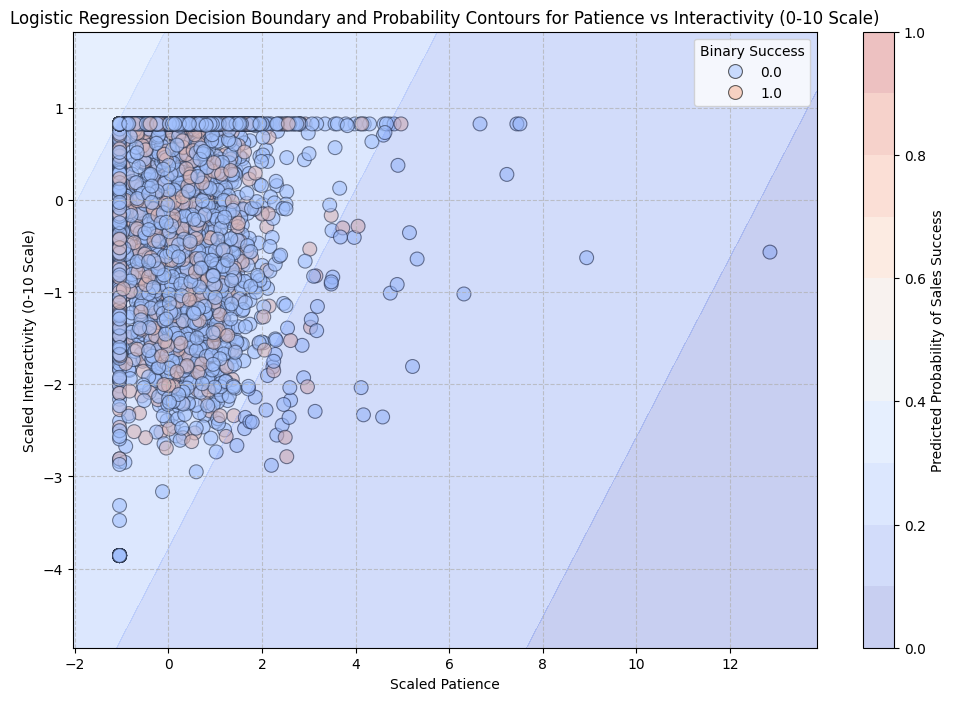

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.linear_model import LogisticRegression

# Select two significant features for 2D visualization
# Using 'Patience' and 'Interactivity (0-10 Scale)' as they were user-specified and significant
feature1_name = 'Patience'
feature2_name = 'Interactivity (0-10 Scale)'

# Extract the selected features and the dependent variable
# Ensure 'const' is dropped from X if present for sklearn model fitting, as it adds its own intercept
X_selected_features = X[[feature1_name, feature2_name]]
y_selected = y

# Train a Logistic Regression model using sklearn for easier decision boundary plotting
# Using 'liblinear' solver for small datasets and 'C' (inverse of regularization strength)
# Since features are scaled, we can use a default C. Larger C means less regularization.
model_2d = LogisticRegression(solver='liblinear', random_state=42)
model_2d.fit(X_selected_features, y_selected)

# Create a meshgrid for plotting the decision boundary
x_min, x_max = X_selected_features[feature1_name].min() - 1, X_selected_features[feature1_name].max() + 1
y_min, y_max = X_selected_features[feature2_name].min() - 1, X_selected_features[feature2_name].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

# Predict probabilities over the meshgrid
Z = model_2d.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
Z = Z.reshape(xx.shape)

# Plotting
plt.figure(figsize=(12, 8))
sns.scatterplot(x=X_selected_features[feature1_name], y=X_selected_features[feature2_name], hue=y_selected,
                palette='coolwarm', alpha=0.6, s=100, edgecolor='k', legend='full')

# Plot the decision boundary (Z=0.5 contour line)
plt.contour(xx, yy, Z, levels=[0.5], linewidths=2, colors='black', linestyles='--')

# Plot the logistic probability contours
plt.contourf(xx, yy, Z, levels=np.linspace(0, 1, 11), cmap='coolwarm', alpha=0.3)

plt.xlabel(f'Scaled {feature1_name}')
plt.ylabel(f'Scaled {feature2_name}')
plt.title(f'Logistic Regression Decision Boundary and Probability Contours for {feature1_name} vs {feature2_name}')
plt.colorbar(label='Predicted Probability of Sales Success')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

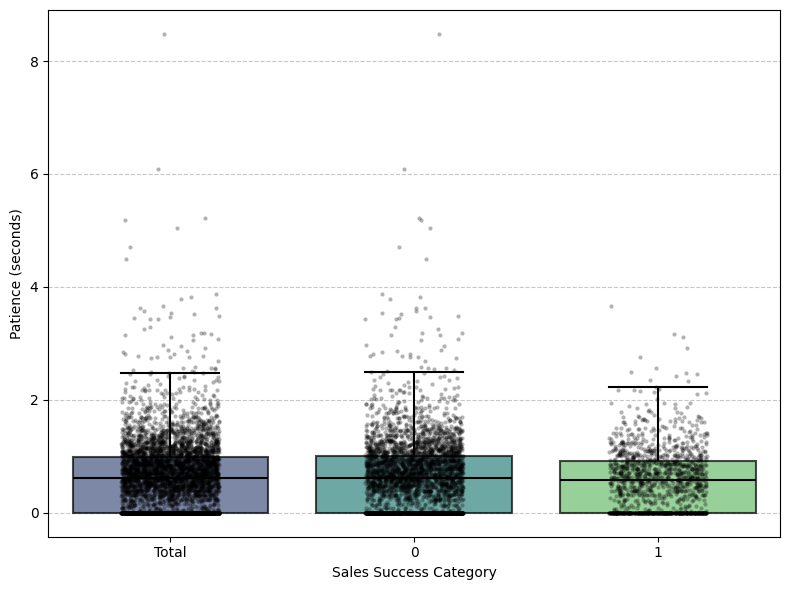

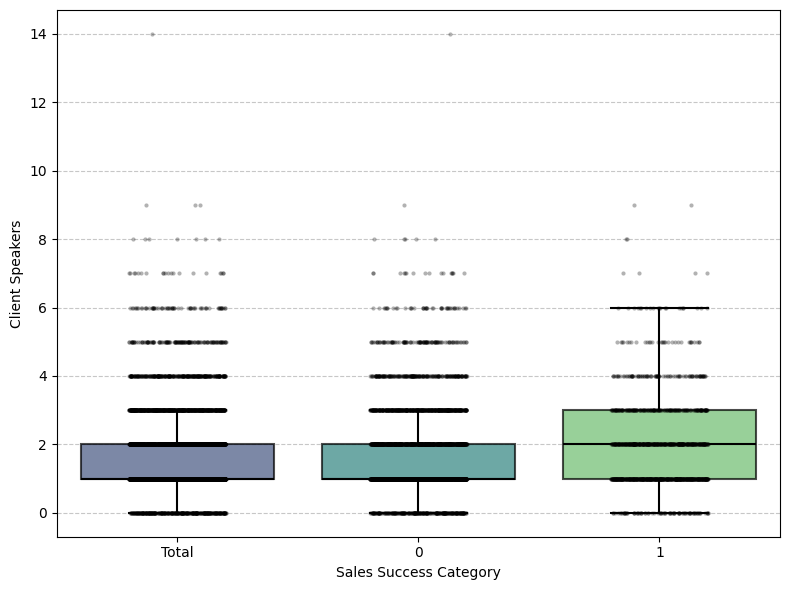

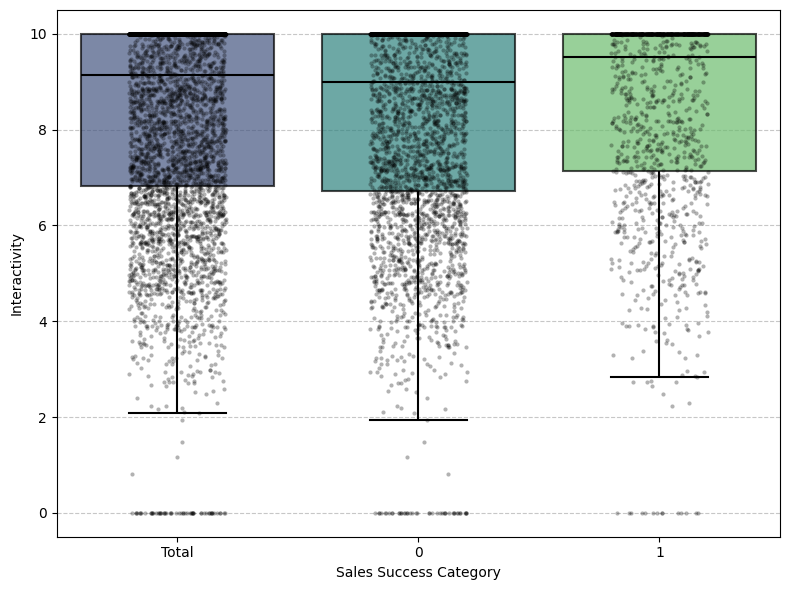

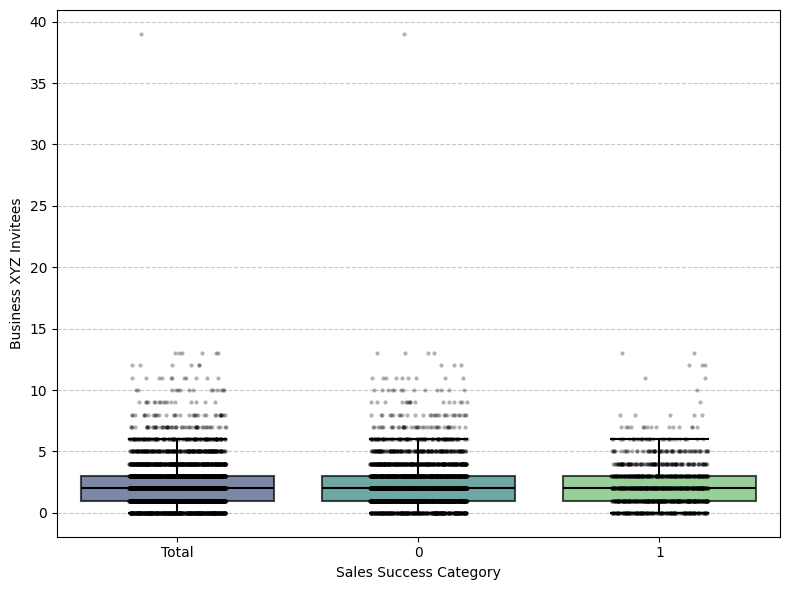


Descriptive Statistics for Significant Variables:
                 Variable Sales Success  Min (actual)    Q1  Median     Q3  Max (actual)   IQR  Min (no outliers)  Max (no outliers)
0      Patience (seconds)         Total           0.0  0.00    0.61   0.99          8.48  0.99               0.00               2.47
1      Patience (seconds)             0           0.0  0.00    0.62   0.62          8.48  0.62               0.00               1.54
2      Patience (seconds)             1           0.0  0.00    0.58   0.58          3.67  0.58               0.00               1.43
3         Client Speakers         Total           0.0  1.00    1.00   2.00         14.00  1.00               0.00               3.00
4         Client Speakers             0           0.0  1.00    1.00   1.00         14.00  0.00               1.00               1.00
5         Client Speakers             1           0.0  1.00    2.00   2.00          9.00  1.00               0.00               3.00
6           Intera

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import statsmodels.api as sm
import numpy as np
from sklearn.preprocessing import StandardScaler
from google.colab import files
import os

# --- Start of Data Loading and Preprocessing for X and y (copied from earlier steps) ---

# Check if the file exists, if not, prompt for upload
file_path = '/content/AP Research Call Data - Call Data.csv'
if not os.path.exists(file_path):
    print("AP Research Call Data - Call Data.csv not found. Please upload the file.")
    uploaded = files.upload()
    for fn in uploaded.keys():
        print('User uploaded file "{name}" with length {length} bytes'.format(
            name=fn, length=len(uploaded[fn])))
    if 'AP Research Call Data - Call Data.csv' not in uploaded:
        print("Error: AP Research Call Data - Call Data.csv was not uploaded. Please upload the correct file.")
        raise FileNotFoundError("AP Research Call Data - Call Data.csv not uploaded.")

# Load the CallData.csv file into a Pandas DataFrame
df = pd.read_csv(file_path)

# Identify column indices for selection
columns = df.columns.tolist()
d_col_index = columns.index('Duration (Sec.)')
ae_col_index = columns.index('Deal Stage (After)')
aj_col_index = columns.index('Binary Success')
ak_col_index = columns.index('Verbal AS-IS (generic phrases) - # Occurrences')
bd_col_index = columns.index('Wrap-Up')

# Select the dependent variable (AJ)
y = df.iloc[:, aj_col_index]

# Select independent variables (D to AE and AK to BD)
X_part1 = df.iloc[:, d_col_index : ae_col_index + 1]
X_part2 = df.iloc[:, ak_col_index : bd_col_index + 1]
X_unscaled_original_features = pd.concat([X_part1, X_part2], axis=1) # Store original features here

# Remove rows from both X and y where the dependent variable y ('Binary Success') has missing values.
non_null_indices = y.dropna().index
X_unscaled_original_features = X_unscaled_original_features.loc[non_null_indices]
y = y.loc[non_null_indices]

# Drop the original categorical columns 'Deal Stage (After)' and 'Deal Stage (Before)' from X.
columns_to_drop = ['Deal Stage (After)', 'Deal Stage (Before)']
X_unscaled_original_features = X_unscaled_original_features.drop(columns=columns_to_drop, errors='ignore')

# Identify numerical columns in X that still contain missing values and impute them with the mean.
missing_values_count = X_unscaled_original_features.isnull().sum()
missing_numerical_cols = missing_values_count[missing_values_count > 0].index.tolist()
for col in missing_numerical_cols:
    if X_unscaled_original_features[col].dtype in ['int64', 'float64']:
        X_unscaled_original_features[col] = X_unscaled_original_features[col].fillna(X_unscaled_original_features[col].mean())

# Confirm that all remaining columns in X are numerical.
non_numerical_cols = X_unscaled_original_features.select_dtypes(include=['object', 'category']).columns.tolist()
if non_numerical_cols:
    X_unscaled_original_features = pd.get_dummies(X_unscaled_original_features, columns=non_numerical_cols, drop_first=True)

# Ensure y is binary (0 or 1)
if not y.isin([0, 1]).all():
    y = (y > 0).astype(int)

# --- End of Data Loading and Preprocessing for X and y ---
# Note: Scaling step is skipped for X_unscaled_original_features for this plot

# Map user-friendly names to actual DataFrame column names
variable_mapping = {
    'Patience (seconds)': 'Patience',
    'Client Speakers': 'Non-HighRadius Speaker Count',
    'Interactivity': 'Interactivity (0-10 Scale)',
    'Business XYZ Invitees': 'HighRadius Invitee Count'
}

# Prepare the data for plotting using the unscaled data
X_plot_unscaled = X_unscaled_original_features[list(variable_mapping.values())].copy()

df_plot = pd.concat([X_plot_unscaled.reset_index(drop=True), y.reset_index(drop=True)], axis=1)
df_plot = df_plot.rename(columns={'Binary Success': 'Sales Success'})

# Generate individual box plots with 'Total' category
for user_friendly_name, original_col_name in variable_mapping.items():
    # Prepare data for plotting with 'Total' category
    plot_data_success = pd.DataFrame()
    plot_data_success['Value'] = df_plot[original_col_name]
    plot_data_success['Category'] = df_plot['Sales Success'].astype(int).astype(str) # Categories '0' and '1'

    total_data_plot = pd.DataFrame()
    total_data_plot['Value'] = df_plot[original_col_name]
    total_data_plot['Category'] = 'Total'

    combined_plot_data = pd.concat([total_data_plot, plot_data_success])

    plt.figure(figsize=(8, 6))
    # Create the boxplot with showfliers=False and decreased opacity
    sns.boxplot(x='Category', y='Value', data=combined_plot_data, palette='viridis', hue='Category', legend=False, order=['Total', '0', '1'], showfliers=False,
                boxprops=dict(alpha=0.7, edgecolor='black', linewidth=1.5),
                whiskerprops=dict(color='black', linewidth=1.5),
                capprops=dict(color='black', linewidth=1.5),
                medianprops=dict(color='black', linewidth=1.5))
    # Overlay stripplot for individual data points with jitter and decreased opacity
    sns.stripplot(x='Category', y='Value', data=combined_plot_data, color='black', size=3, jitter=0.2, alpha=0.3, order=['Total', '0', '1'])
    # Removed plt.title()
    plt.xlabel('Sales Success Category')
    plt.ylabel(f'{user_friendly_name}')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# Calculate and print descriptive statistics with 'Total' row
print("\nDescriptive Statistics for Significant Variables:")
stats_data = []

for user_friendly_name, original_col_name in variable_mapping.items():
    # Add Total row for the variable
    total_subset = df_plot[original_col_name]
    q1_total = total_subset.quantile(0.25)
    median_total = total_subset.median()
    q3_total = total_subset.quantile(0.75)
    iqr_total = q3_total - q1_total
    lower_whisker_total = total_subset[total_subset >= (q1_total - 1.5 * iqr_total)].min()
    upper_whisker_total = total_subset[total_subset <= (q3_total + 1.5 * iqr_total)].max()
    stats_data.append({
        'Variable': user_friendly_name,
        'Sales Success': 'Total',
        'Min (actual)': total_subset.min(),
        'Q1': q1_total,
        'Median': median_total,
        'Q3': q3_total,
        'Max (actual)': total_subset.max(),
        'IQR': iqr_total,
        'Min (no outliers)': lower_whisker_total,
        'Max (no outliers)': upper_whisker_total
    })

    # Add rows for Sales Success 0 and 1 (existing logic)
    for success_val in sorted(df_plot['Sales Success'].unique()):
        subset = df_plot[df_plot['Sales Success'] == success_val][original_col_name]
        q1 = subset.quantile(0.25)
        median = subset.median()
        q3 = subset.median()
        iqr = q3 - q1 # Calculate IQR

        # Calculate whisker boundaries (min/max without outliers)
        lower_whisker = subset[subset >= (q1 - 1.5 * iqr)].min()
        upper_whisker = subset[subset <= (q3 + 1.5 * iqr)].max()

        stats_data.append({
            'Variable': user_friendly_name,
            'Sales Success': int(success_val),
            'Min (actual)': subset.min(), # Actual min
            'Q1': q1,
            'Median': median,
            'Q3': q3,
            'Max (actual)': subset.max(), # Actual max
            'IQR': iqr,
            'Min (no outliers)': lower_whisker,
            'Max (no outliers)': upper_whisker
        })

stats_df = pd.DataFrame(stats_data)
print(stats_df.to_string())